# Assignment 2 - Numbers to Neurons

---
> Complete each question below. Write theory answers in Markdown cells and code in code cells.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

---
## Q1 - Perceptrons and Sigmoid Neurons

### Q1a - NAND Perceptron

Write a Python class using NumPy that implements a **NAND logic gate** using a single perceptron. Your implementation must use **vectorized operations** (no explicit `for` loops in the activation function) to process an input matrix of shape `(N, 2)` and return the corresponding binary outputs.

Mathematically determine and set the correct weights and bias within your code.

In [2]:
#code here
class NANDPerceptron:
  def __init__(self):
    self.weights = np.array([-2.0, -2.0])
    self.bias = 3.0

  def forward(self, x):
    z = np.dot(x, self.weights) + self.bias
    return (z >= 0).astype(int)

### Q1b - Perceptron Sensitivity

Explain precisely why a tiny change in one weight can cause **chaos** in a perceptron network. What property of the perceptron makes this happen?

> **Your answer:** Discontinuity, The perceptron range is limited to only 2 values which are provided by inequality. So if we change the weight a bit, it has the potential to flip the output completely

### Q1c - Sigmoid to Perceptron Limit

Suppose you multiply all the weights and bias of a sigmoid neuron by a positive constant c > 0.

1. As c approaches what value will this sigmoid neuron behave exactly like a classic perceptron? Why mathematically?
2. Explain in 2-3 lines why we prefer sigmoid neurons over perceptrons.

> **Your answer:** When c approches infinity. then the values will either be 0 or 1.
sigmoid neurons are continuor and smooth so we can use and tune and fine the values even further by gradient descent. the gradient of perceptron is 0.

---
## Q2 - The Quadratic Cost Function

$$C(w,b) = \frac{1}{2n} \sum_x \|y(x) - a\|^2$$

### Q2a - The Factor of 1/2

Why is there a factor of 1/2 in front? Derive why it is mathematically convenient when computing the derivative of C with respect to any weight w.

> **Your answer:**

### Q2b - Computing C by Hand

A network has two training examples:
- Example 1: output = 0.9, target = 1.0
- Example 2: output = 0.3, target = 0.0

Compute C by hand and explain what the value tells you about network performance.

> **Your answer:** when we take derivative of C we get 2 in numerator which cancels out the 2 in denominator.
0.1/4=0.025

In [5]:
# Verify your hand computation
outputs = np.array([0.9, 0.3])
targets = np.array([1.0, 0.0])

n = len(outputs)
c_val = (1 / (2 * n)) * np.sum((targets - outputs) ** 2)
print(f'C = {c_val}')

C = 0.024999999999999998


### Q2c - Cost vs Accuracy

Explain why we use a cost function and do **not** directly maximise classification accuracy.

> **Your answer:** Accracy is a binary type of thing, either something is right or wrong. it wont help with tuning vaues like gradient descent does.

### Q2d - Absolute Error vs Squared Error

An alternative cost is the absolute error: C = (1/n) * sum |y(x) - a|.

Explain **one mathematical problem** with using absolute error instead of squared error, specifically when doing gradient descent.

> **Your answer:** the gradient is not continuous.

---
## Q3 - Gradient Descent on a Toy Cost Function

$$C(w, b) = (w - 3)^2 + 2(b - 1)^2$$

### Q3a - Minimum by Inspection

By inspection, what values of w and b minimise C? What is the minimum value of C? Explain your reasoning without calculus.

> **Your answer:** w=3 and b=1
cmin=0
range is positive and zero. minimum is 0.

### Q3b - Two Steps by Hand

Compute dC/dw and dC/db. Starting from (w, b) = (0, 0) with learning rate eta = 0.1, show the first two gradient descent update steps by hand. Where does the parameter vector end up after step 2?

> **Your answer:** dC/dw=2(w-3)=-6
                   dC/db=4(b-1)=-4
    
  w1=0-0.1*(-6)=0.06   b1=0-0.1*(-4)=0.4
                   dC/dw=2(w-3)=-4.8
                   dC/db=4(b-1)=-2.4

  w2=0.6-0.1(-4.8)=1.0  b2=0.4-0.1(-2.4) =0.64


In [6]:
def cost(w, b):
    return (w - 3)**2 + 2*(b - 1)**2

def grad_cost(w, b):
    dw = 2*(w-3)
    db = 4*(b-1)
    return dw, db

# Verify your hand calculation
eta = 0.1
w, b = 0.0, 0.0
for step in range(1, 3):
    dw, db = grad_cost(w, b)
    w = w - eta * dw
    b = b - eta * db
    print(f'Step {step}: w={w:.4f}, b={b:.4f}, C={cost(w,b):.4f}')

Step 1: w=0.6000, b=0.4000, C=6.4800
Step 2: w=1.0800, b=0.6400, C=3.9456


### Q3c - Too-Large Learning Rate

If you set eta = 0.6, what goes wrong on the b update? Show numerically. What does this tell you about learning rate selection?

> **Your answer:** Error increases.

In [8]:
eta_bad = 0.6
w, b = 0.0, 0.0
for step in range(1, 5):
    dw, db = grad_cost(w, b)
    w = w - eta_bad * dw
    b = b - eta_bad * db
    print(f'Step {step}: w={w:.4f}, b={b:.4f}, C={cost(w,b):.4f}')

Step 1: w=3.6000, b=2.4000, C=4.2800
Step 2: w=2.8800, b=-0.9600, C=7.6976
Step 3: w=3.0240, b=3.7440, C=15.0596
Step 4: w=2.9952, b=-2.8416, C=29.5158


---
## Q4 - Sigmoid Neuron: Implementation and Visualisation

In [9]:
class SigmoidNeuron:

    def __init__(self, weights, bias):
        self.weights = np.array(weights, dtype=float)
        self.bias = float(bias)

    def forward(self, x):
        # TODO: compute z = w.x + b, return sigmoid(z)
        z=np.dot(x,self.weights)+self.bias
        return 1/(1+np.exp(-z))


    def numerical_gradient(self, x, h=1e-5):
        # TODO: centered difference (f(x+h) - f(x-h)) / 2h
        # return (grad_weights, grad_bias)
        grad_weights = np.zeros_like(self.weights)
        for i in range(len(self.weights)):
          original_weight = self.weights[i]
          self.weights[i] = original_weight + h
          f_plus = self.forward(x)
          self.weights[i] = original_weight - h
          f_minus = self.forward(x)
          grad_weights[i] = (f_plus - f_minus) / (2 * h)
          self.weights[i] = original_weight

        original_bias = self.bias
        self.bias = original_bias + h
        f_plus_bias = self.forward(x)
        self.bias = original_bias - h
        f_minus_bias = self.forward(x)
        grad_bias = (f_plus_bias - f_minus_bias) / (2 * h)
        self.bias = original_bias
        return grad_weights, grad_bias



### Q4a - Forward Pass and Gradients

For weights=[2, -1] and bias=0.5, compute the output and all gradients at x=[1, 1]. Explain what the gradient w.r.t. w1 means in plain English.

In [10]:
neuron = SigmoidNeuron(weights=[2, -1], bias=0.5)
x = np.array([1.0, 1.0])

output = neuron.forward(x)
grad_w, grad_b = neuron.numerical_gradient(x)

print(f'Output:        {output}')
print(f'd(output)/dw1: {grad_w[0]:.6f}')
print(f'd(output)/dw2: {grad_w[1]:.6f}')
print(f'd(output)/db:  {grad_b:.6f}')

Output:        0.8175744761936437
d(output)/dw1: 0.149146
d(output)/dw2: 0.149146
d(output)/db:  0.149146


**Explanation of gradient w.r.t. w1:**

> **Your answer:** the gradient after of 2nd weight in array

### Q4b - Plot sigma(z) and sigma'(z)

Plot sigma(z) and its derivative sigma'(z) = sigma(z)(1 - sigma(z)) for z in [-10, 10].

- At what value of z is the gradient largest?
- What happens as z approaches +/- infinity and why is this a problem (vanishing gradient)?

> **Your answer:** z=0
the curve flattens.

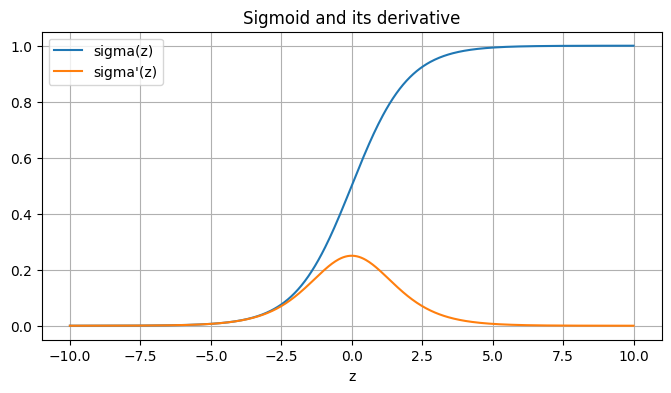

In [11]:
z = np.linspace(-10, 10, 500)

# TODO: compute sigma and sigma_prime
sigma       = 1.0/(1.0+np.exp(-z))
sigma_prime = sigma*(1-sigma)

plt.figure(figsize=(8, 4))
# TODO: plot both curves
plt.plot(z, sigma, label='sigma(z)')
plt.plot(z, sigma_prime, label='sigma\'(z)')
plt.xlabel('z')
plt.legend()
plt.title('Sigmoid and its derivative')
plt.grid(True)
plt.show()

### Q4c - Is sigma(100z) basically a perceptron?

A classmate claims: 'a sigmoid neuron with weights multiplied by 100 is basically the same as a perceptron.'

Plot sigma(100z) vs sigma(z) vs the step function. Is the claim correct? Under what condition does it break down?

> **Your answer:** yes when z=0 the clain in broken.

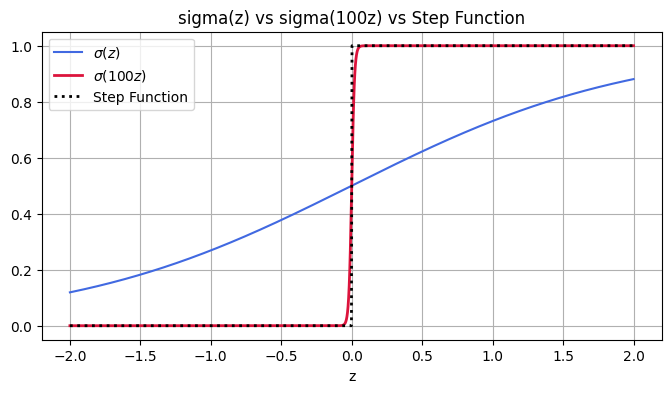

In [15]:
z = np.linspace(-2, 2, 1000)

# TODO: compute sigma(z), sigma(100*z), step function
sigma= 1.0/(1.0+np.exp(-z))
sigma_100= 1.0/(1.0+np.exp(-100*z))
step_function=(z >= 0).astype(float)

plt.figure(figsize=(8, 4))
# TODO: plot all three

plt.plot(z, sigma, label=r'$\sigma(z)$', color='royalblue', linewidth=1.5)
plt.plot(z, sigma_100, label=r'$\sigma(100z)$', color='crimson', linewidth=2)
plt.plot(z, step_function, label='Step Function', color='black', linestyle=':', linewidth=2)
plt.title('sigma(z) vs sigma(100z) vs Step Function')
plt.xlabel('z')
plt.legend()
plt.grid(True)
plt.show()

---
## Q5 - Gradient Descent on a Toy Regression Problem

A single-layer network (one input, one output, no activation) must learn y = 3x + 1.

In [17]:
X_train = np.array([0.0, 1.0, 2.0, 3.0, 4.0])
y_train = np.array([1.0, 4.0, 7.0, 10.0, 13.0])

### Q5a - Analytical Gradients + Full-Batch GD

Derive dC/dw and dC/db analytically (show algebra). Implement full-batch GD with eta = 0.01 for 200 epochs. Plot the loss curve. Do w and b converge to 3 and 1?

**Derivation (show algebra):**

> **Your answer:**

C(w,b)=1/2n(sum(ai-yi)^2)
ai=wxi+b
C(w,b)=1/2n(sum(wxi+b-yi)^2)
dC/dw=1/2n(sum(2(wxi+b-yi)))*d/dw(wxi+b-yi)

dC/dw=1/n(sum(wxi+b-yi).xi)

dC/db=1/2n(sum(2(wxi+b-yi)))*d/db(wxi+b-yi)

dC/db=1/n(sum(wxi+b-yi))



Final w = 2.9963, b = 1.0104


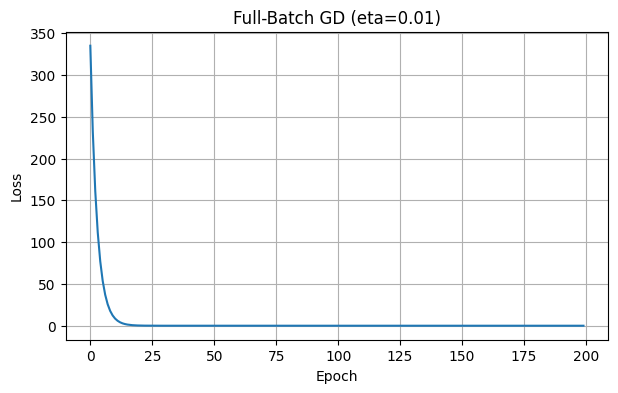

In [19]:
w, b = 0.0, 0.0
eta = 0.01
losses = []

for epoch in range(200):
  pred=w*X_train+b

  # TODO: predictions, loss, gradients, update
  loss = (1/2*n)*np.sum((pred-y_train)**2)
  losses.append(loss)
  dw=(1/n)*np.sum((pred-y_train)*X_train)
  db=(1/n)*np.sum((pred-y_train))
  w=w-eta*dw
  b=b-eta*db


print(f'Final w = {w:.4f}, b = {b:.4f}')
plt.figure(figsize=(7, 4))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Full-Batch GD (eta=0.01)')
plt.grid(True)
plt.show()

### Q5b - SGD with Mini-Batch Size = 1

Implement SGD with batch size 1. Train 200 epochs with eta = 0.01. Plot the loss curve. How does it differ from full-batch? Explain in terms of gradient quality and noise.

> **Your answer:**

Final w = 2.1957, b = 1.4832


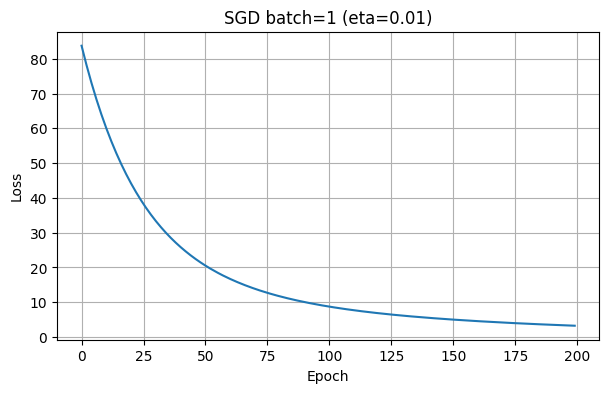

In [22]:
w, b = 0.0, 0.0
eta = 0.01
losses_sgd = []
np.random.seed(42)

for epoch in range(200):
  epoch_predictions = w * X_train + b
  loss = (1 / (2 * n)) * np.sum((epoch_predictions - y_train) ** 2)
    # TODO: pick random example, compute gradient, update
  losses_sgd.append(loss)
  indices = np.random.permutation(n)
  for idx in indices:
        xi = X_train[idx]
        yi = y_train[idx]
        pred_i = w * xi + b
        error_i = pred_i - yi
        dw_i = error_i * xi
        db_i = error_i
        w = w - eta * dw_i
        b = b - eta * db_i

print(f'Final w = {w:.4f}, b = {b:.4f}')
plt.figure(figsize=(7, 4))
plt.plot(losses_sgd)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('SGD batch=1 (eta=0.01)')
plt.grid(True)
plt.show()

### Q5c - Divergence with eta = 0.5

Set eta = 0.5 with full-batch GD. Show the loss curve and explain using the gradient formulas from Q5a why it diverges.

> **Your answer:**
db = 1/5(sum(wx_i + b - y_i))
dw=1/5(sum(wxi+b-yi)xi)
sum(xi)=10 sum(xi^2)=30

dw=6w=2b
db=2w+b

wnew=w-0.5(6w+2b)=-2w-b

factor of w is -2. itsnot gona lessen it will keep increasing


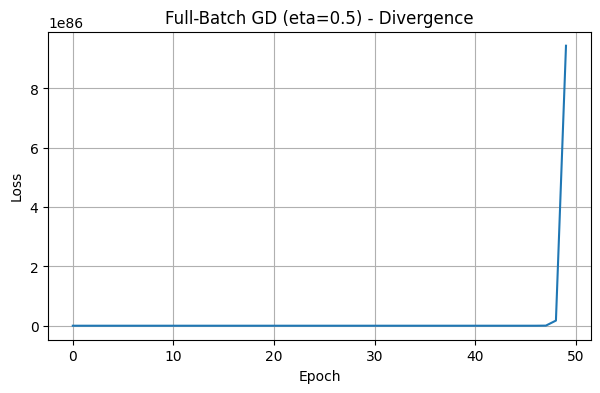

In [28]:
w, b = 0.0, 0.0
losses_div = []
eta = 0.5
for epoch in range(50):
    # TODO: full-batch GD with eta=0.5
    predictions=w*X_train+b
    loss = (1 / (2 * n)) * np.sum((predictions - y_train) ** 2)
    losses_div.append(loss)
    if loss is not None and not np.isfinite(loss):
        print(f'Diverged at epoch {epoch}')
        break

    error = predictions - y_train
    dw = (1 / n) * np.dot(error, X_train)
    db = (1 / n) * np.sum(error)


    w = w - eta * dw
    b = b - eta * db

plt.figure(figsize=(7, 4))
plt.plot(losses_div)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Full-Batch GD (eta=0.5) - Divergence')
plt.grid(True)
plt.show()

---
## Q6 - One-Hot to 4-Bit Binary Encoding Layer

A network classifies digits 0-9 with a 10-neuron one-hot output. Design a final **4-neuron layer** that converts this into a **4-bit binary** encoding (e.g. digit 5 outputs 0101). Specify the weight matrix and bias vector.

**Design and Reasoning:**

> **Your answer:**

In [ ]:
# TODO: define W (4x10) and b_enc (4,)
W     = None  # shape (4, 10)
b_enc = None  # shape (4,)

def threshold(x):
    return (x >= 0.5).astype(int)

print('Digit | Output | Expected | OK?')
print('-' * 35)
for digit in range(10):
    one_hot = np.zeros(10)
    one_hot[digit] = 1.0
    out = threshold(W @ one_hot + b_enc)
    expected = format(digit, '04b')
    ok = 'OK' if ''.join(map(str, out)) == expected else 'FAIL'
    print(f'  {digit}   |  {out}  |  {expected}  | {ok}')

---
## Q7 - Geometric Interpretation of 1D Gradient Descent

Consider C(v) as a function of a single scalar v.

1. Give a precise **geometric interpretation** of the update rule v = v - alpha * dC/dv.
2. How do the slope and the learning rate alpha physically dictate movement along the curve?

> **Your answer:** the slope of tangent lie touching the cost curve at v

learning rae acts as scaling value

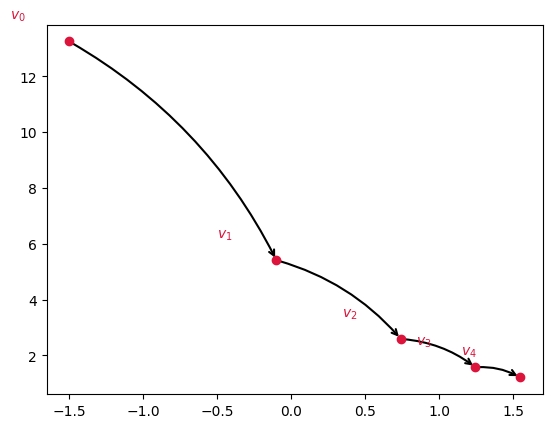

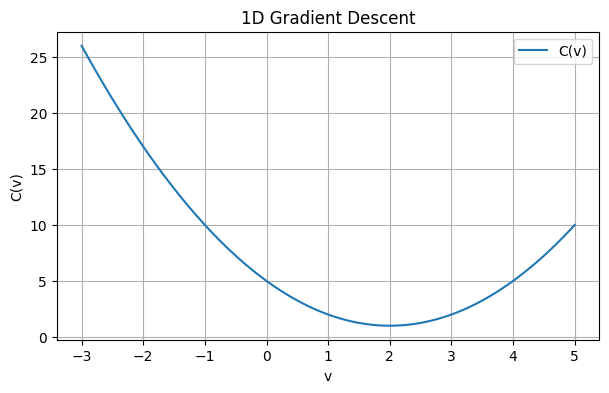

In [29]:
v_vals = np.linspace(-3, 5, 300)
def cost_func(v):
    return (v - 2)**2 + 1
C_v = cost_func(v_vals)

def grad_func(v):
    return 2 * (v - 2)

# TODO: run gradient descent steps and annotate on the curve

v = -1.5
alpha = 0.2
steps = 5

for i in range(steps):
    c_current = cost_func(v)
    g_current = grad_func(v)
    plt.scatter(v, c_current, color='crimson', zorder=5)
    plt.text(v - 0.4, c_current + 0.8, f'$v_{i}$', fontsize=10, weight='bold', color='crimson')

    v_next = v - alpha * g_current
    c_next = cost_func(v_next)


    plt.annotate('', xy=(v_next, c_next), xytext=(v, c_current),
                 arrowprops=dict(arrowstyle="->", color='black', lw=1.5, connectionstyle="arc3,rad=-0.15"))


    v = v_next
plt.figure(figsize=(7, 4))
plt.plot(v_vals, C_v, label='C(v)')
plt.xlabel('v')
plt.ylabel('C(v)')
plt.title('1D Gradient Descent')
plt.legend()
plt.grid(True)
plt.show()

---
## Q8 - Zero Hidden Layers: What Model Are You Really Training?

Suppose you remove all hidden layers, connecting 784 inputs directly to 10 outputs, trained with SGD.

1. What **mathematical model** have you effectively created?
2. Why is classification accuracy **fundamentally capped**?
3. What does this imply about the **necessity of hidden layers**?

> **Your answer:**
Classification model like Logisitic regression
it is forced to learn what it sees on the baseline
hidden layers act as feature extractions